# Clase 3: Tratamiento y Manipulación de datos 


* Franco Mansilla Ibáñez (www.francomansilla.com)

## Descripción
El tratamiento y manipulación de datos corresponde al conjunto de procesos mediante los cuales los datos crudos (raw data) son transformados en un conjunto de datos limpio, consistente y adecuado para su análisis y modelamiento. Este proceso incluye actividades como la detección y corrección de errores, el tratamiento de valores faltantes, la identificación de datos atípicos, la transformación de variables, la estandarización de formatos y la generación de nuevas variables.

En la práctica, los datos provenientes de sistemas reales suelen presentar múltiples problemas: registros incompletos, inconsistencias entre fuentes, errores de captura, escalas heterogéneas, categorías mal definidas y valores extremos que no representan el comportamiento típico del fenómeno estudiado. El tratamiento de datos busca corregir estas deficiencias para garantizar que los análisis posteriores sean válidos y confiables.

## Importancia en Machine Learning
En Machine Learning, la calidad de los datos es un factor determinante del desempeño de los modelos. Un modelo entrenado con datos mal tratados tenderá a aprender patrones espurios, a sobreajustarse a errores del dataset o simplemente a producir predicciones poco confiables, independientemente de la sofisticación del algoritmo utilizado.

Diversos estudios y experiencias prácticas indican que entre el 60% y el 80% del tiempo total de un proyecto de analítica se destina a tareas de preparación de datos, lo que refleja su relevancia dentro del ciclo de vida de un proyecto de ciencia de datos.

Un adecuado tratamiento de datos permite:
- Reducir el ruido y la variabilidad no informativa.
- Evitar sesgos introducidos por valores extremos o datos faltantes.
- Mejorar la estabilidad numérica de los algoritmos.
- Incrementar la capacidad predictiva de los modelos.
- Aumentar la interpretabilidad de los resultados.

## Relación con la generalización del modelo
El objetivo fundamental del Machine Learning es la generalización, es decir, que el modelo sea capaz de realizar buenas predicciones sobre datos no observados. Un tratamiento deficiente de los datos puede provocar que el modelo memorice errores o patrones irrelevantes presentes en el conjunto de entrenamiento, afectando directamente su capacidad de generalizar.

Por esta razón, el tratamiento y manipulación de datos no debe entenderse como una etapa meramente técnica, sino como una parte central del proceso científico de modelamiento, donde se toman decisiones que impactan directamente en la validez de las conclusiones y en el valor práctico de las soluciones desarrolladas.


In [45]:
import pandas as pd
import numpy as np
import ssl #Autorización si es confiable
from sklearn.model_selection import train_test_split
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer




1) Importar una base de datos de forma online

Idea teórica (qué y por qué): 
* En ML normalmente cargamos datos desde una URL (CSV/Parquet) para que el notebook sea reproducible. Con pandas.read_csv(url) puedes traer datos directos desde internet.

In [19]:

ssl._create_default_https_context = ssl._create_unverified_context

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2) Tratamientos de Datos


### 2.1 Estadística descriptiva

Idea teórica: La estadística descriptiva resume el dataset:

* Para numéricas: media, desviación, percentiles (para entender dispersión y rangos).

* Para categóricas: frecuencias (para ver clases dominantes y rarezas).

In [20]:
# Separar tipos de variables
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# Resumen numérico
df[num_cols].describe().T


Numéricas: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categóricas: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [21]:
# Resumen categórico (top valores y frecuencia)
df[cat_cols].describe().T

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


### 2.2 Verificación de datos atípicos y tratamiento (percentil 1 y 99) ##

**Idea teórica:**
Los outliers (atípicos) pueden distorsionar la media, la varianza y afectar modelos sensibles (regresión, kNN, redes, etc.).

Una forma simple de tratarlos es winsorización:

* todo valor < p1 se reemplaza por p1.

* todo valor > p99 se reemplaza por p99.

In [22]:
def winsorize_p1_p99(df, cols):
    df_out = df.copy()
    bounds = {}
    for c in cols:
        p1 = df_out[c].quantile(0.01)
        p99 = df_out[c].quantile(0.99)
        bounds[c] = (p1, p99)
        df_out[c] = df_out[c].clip(lower=p1, upper=p99)
    return df_out, bounds

# Aplicar solo a variables numéricas (ejemplo: todas las numéricas)
df_w, bounds = winsorize_p1_p99(df, num_cols)

bounds  # para ver (p1, p99) por variable


{'PassengerId': (9.9, 882.1),
 'Survived': (0.0, 1.0),
 'Pclass': (1.0, 3.0),
 'Age': (1.0, 65.87),
 'SibSp': (0.0, 5.0),
 'Parch': (0.0, 4.0),
 'Fare': (0.0, 249.00622000000035)}

In [23]:
# Comparación rápida antes vs después (ejemplo con una variable)
col = num_cols[0]
print("Antes:", df[col].min(), df[col].max())
print("Después:", df_w[col].min(), df_w[col].max())

Antes: 1 891
Después: 9.9 882.1


### 2.3 Missing values y tratamiento

#### Categóricas: crear una categoría extra "Missing"

**Continuas: imputar con la media**

**Idea teórica**: Los missing values son normales (encuestas incompletas, fallos de captura, etc.).

Si los ignoras, muchos modelos fallan o pierdes datos al eliminar filas.
Estrategia típica:

* Categóricas: “Missing” conserva la fila y puede capturar señal (“no respondió”).

* Numéricas: media es un baseline simple (hay otras opciones como mediana, modelos de imputación, etc.).

In [24]:
# Conteo de missing
missing_count = df_w.isna().sum().sort_values(ascending=False)
missing_pct = (df_w.isna().mean() * 100).sort_values(ascending=False)

pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct}).head(15)


,missing_count,missing_pct
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


In [25]:
df_clean = df_w.copy()

# 1) Categóricas: categoría adicional
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna("Missing")

# 2) Numéricas: media
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mean())

# Verificar que ya no hay NA
df_clean.isna().sum().sort_values(ascending=False).head(10)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
dtype: int64

## 4) Correlación

**Idea teórica**: La correlación (Pearson) mide relación lineal entre variables numéricas.

**Sirve para:** detectar variables redundantes (muy correlacionadas entre sí), entender relación con el target (si es numérico), anticipar multicolinealidad en modelos lineales.

In [26]:
corr = df_clean[num_cols].corr(method="pearson")
corr


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.004940,-0.035162,0.032162,-0.068998,-0.004251,0.006722
Survived,-0.004940,1.000000,-0.338481,-0.069721,-0.021052,0.091304,0.273008
Pclass,-0.035162,-0.338481,1.000000,-0.332740,0.074633,0.010955,-0.606050
Age,0.032162,-0.069721,-0.332740,1.000000,-0.267113,-0.198267,0.099882
SibSp,-0.068998,-0.021052,0.074633,-0.267113,1.000000,0.445938,0.198128
Parch,-0.004251,0.091304,0.010955,-0.198267,0.445938,1.000000,0.261234
Fare,0.006722,0.273008,-0.606050,0.099882,0.198128,0.261234,1.000000


In [27]:
# Si quieres ver rápidamente las correlaciones más fuertes (en valor absoluto)
corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

top_pairs = upper.stack().sort_values(ascending=False).head(15)
top_pairs


Pclass       Fare      0.606050
SibSp        Parch     0.445938
Survived     Pclass    0.338481
Pclass       Age       0.332740
Survived     Fare      0.273008
Age          SibSp     0.267113
Parch        Fare      0.261234
Age          Parch     0.198267
SibSp        Fare      0.198128
Age          Fare      0.099882
Survived     Parch     0.091304
Pclass       SibSp     0.074633
Survived     Age       0.069721
PassengerId  SibSp     0.068998
             Pclass    0.035162
dtype: float64

## 5) Separación entre muestra de entrenamiento y validación

**Idea teórica:** Separamos datos para medir generalización:

* train: el modelo aprende patrones

* valid/test: el modelo se evalúa en datos no vistos

**Si tu variable objetivo (target) es categórica, conviene usar stratify para mantener proporciones.**

In [28]:

target = "Survived"

X = df_clean.drop(columns=[target])
y = df_clean[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantiene proporción de clases
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)

# Chequear proporciones
print("y total:", y.value_counts(normalize=True))
print("y train:", y_train.value_counts(normalize=True))
print("y val:  ", y_val.value_counts(normalize=True))


Train: (712, 11) (712,)
Val:   (179, 11) (179,)
y total: Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
y train: Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
y val:   Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## 6. Análisis previo: poder discriminante de variables continuas

## Objetivo
Antes de entrenar un modelo de Machine Learning, es recomendable evaluar qué variables realmente aportan información para discriminar entre clases. Este análisis permite identificar variables relevantes y descartar aquellas que no contienen señal predictiva.

## Idea estadística
Si una variable es útil para clasificar, entonces su media en la clase 0 debería ser distinta de su media en la clase 1. Para evaluar esto se utiliza una prueba de diferencia de medias (t-test de dos muestras independientes).

## Hipótesis
- Hipótesis nula (H0): las medias de ambas clases son iguales.
- Hipótesis alternativa (H1): las medias de ambas clases son distintas.

## Significancia estadística
El p-value indica la probabilidad de observar una diferencia de medias al menos tan grande como la observada si la hipótesis nula fuera verdadera.
- p-value < 0.05: diferencia estadísticamente significativa.
- p-value ≥ 0.05: no hay evidencia suficiente de discriminación.

## Interpretación final
Este análisis permite construir un ranking de variables según su poder discriminante, funcionando como una primera aproximación teórica a la importancia de variables antes de entrenar cualquier modelo de Machine Learning.


In [29]:
target = "Survived"
results = []

for col in num_cols:
    if col == target:
        continue
    
    group0 = df_clean[df_clean[target] == 0][col]
    group1 = df_clean[df_clean[target] == 1][col]
    
    t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=False)
    
    mean0 = group0.mean()
    mean1 = group1.mean()
    
    diff_means = mean1 - mean0
    
    pooled_std = np.sqrt((group0.var() + group1.var()) / 2)
    cohens_d = diff_means / pooled_std
    
    results.append({
        "variable": col,
        "mean_class_0": mean0,
        "mean_class_1": mean1,
        "diff_means": diff_means,
        "p_value": p_value,
        "cohens_d": cohens_d
    })

df_discrimination = pd.DataFrame(results)

df_discrimination = df_discrimination.sort_values(
    by="cohens_d",
    key=np.abs,
    ascending=False
)

df_discrimination


,variable,mean_class_0,mean_class_1,diff_means,p_value,cohens_d
1,Pclass,2.531876,1.950292,-0.581584,2.911155e-23,-0.725076
5,Fare,22.066908,45.925542,23.858634,2.270423e-13,0.548490
4,Parch,0.318761,0.461988,0.143227,6.301292e-03,0.188524
2,Age,30.343948,28.504505,-1.839443,4.232215e-02,-0.141810
3,SibSp,0.515483,0.473684,-0.041798,4.897669e-01,-0.045270
0,PassengerId,447.002186,444.391228,-2.610958,8.820641e-01,-0.010185


## 7. Visualización de la variable más discriminante

## Objetivo
Una vez identificada la variable con mayor poder discriminante mediante la prueba t de Student, es fundamental analizar visualmente cómo se distribuye dicha variable en cada una de las clases del target.

El histograma permite observar:
- La forma de la distribución (simetría, sesgo, colas).
- El grado de superposición entre clases.
- La separación real entre grupos.

Si una variable es realmente discriminante, se espera que las distribuciones de ambas clases estén desplazadas entre sí, con baja superposición.


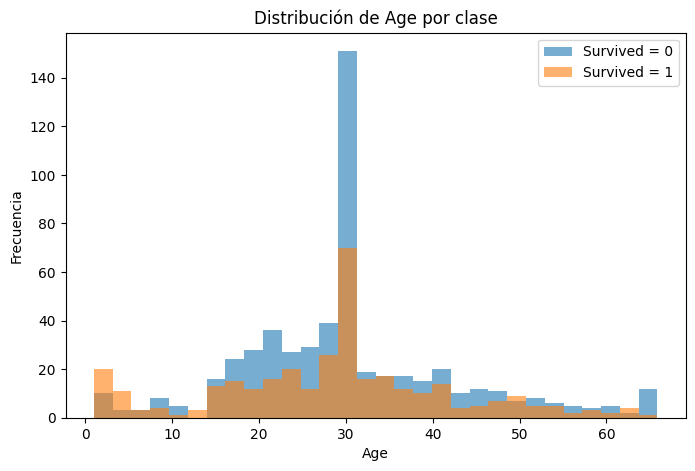

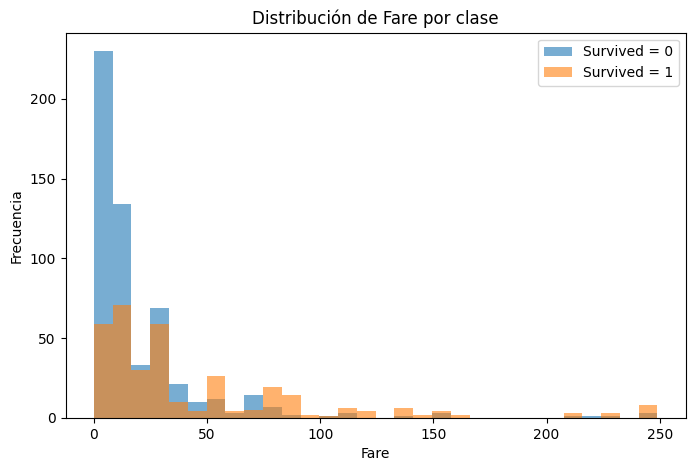

In [30]:
import matplotlib.pyplot as plt

variables = ["Age", "Fare"]

for var in variables:
    
    data_0 = df_clean[df_clean[target] == 0][var]
    data_1 = df_clean[df_clean[target] == 1][var]
    
    plt.figure(figsize=(8, 5))
    plt.hist(data_0, bins=30, alpha=0.6, label="Survived = 0")
    plt.hist(data_1, bins=30, alpha=0.6, label="Survived = 1")
    
    plt.title(f"Distribución de {var} por clase")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()


# Clase 4: Modelos de clasificación y métricas de validación

## Objetivo
El objetivo es entrenar y comparar tres modelos de clasificación binaria:

1. Regresión Logística.
2. Modelo Elastic Net (regresión logística regularizada).
3. Random Forest.

Estos modelos se evaluarán utilizando dos métricas:

- F1-score: balance entre precisión (precision) y exhaustividad (recall).
- KS (Kolmogorov-Smirnov): medida de separación entre las distribuciones
  de probabilidades predichas para las dos clases.

## Métrica F1
El F1-score es la media armónica entre precisión y recall:

F1 = 2 * (precision * recall) / (precision + recall)

Es especialmente útil cuando las clases están desbalanceadas.

## Métrica KS
El estadístico KS mide la máxima diferencia entre las funciones de
distribución acumulada de las probabilidades predichas para cada clase.

En riesgo y scoring:
- KS cercano a 0 → modelo malo.
- KS entre 0.2 y 0.4 → modelo aceptable.
- KS > 0.4 → modelo bueno.


In [37]:
num_cols_model = [c for c in num_cols if c != target]

X_train_num = X_train[num_cols_model]
X_val_num   = X_val[num_cols_model]


## Regresión logística

La regresión logística es un modelo probabilístico lineal que estima
la probabilidad de pertenecer a una clase mediante la función logística:

$$P(Y=1|X) = 1 / (1 + exp(-(β0 + β1X1 + ... + βpXp)))$$

Es el modelo base en problemas de clasificación:
- altamente interpretable
- estable
- fácil de explicar
- benchmark de referencia en industria.


In [41]:
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_num, y_train)

# Train
y_pred_train = logit.predict(X_train_num)
y_prob_train = logit.predict_proba(X_train_num)[:,1]

# Validation
y_pred_val = logit.predict(X_val_num)
y_prob_val = logit.predict_proba(X_val_num)[:,1]

f1_train_logit = f1_score(y_train, y_pred_train)
f1_val_logit   = f1_score(y_val, y_pred_val)

ks_train_logit = ks_2samp(
    y_prob_train[y_train==0],
    y_prob_train[y_train==1]
).statistic

ks_val_logit = ks_2samp(
    y_prob_val[y_val==0],
    y_prob_val[y_val==1]
).statistic


## Elastic Net

Elastic Net es una extensión de la regresión logística que incorpora
regularización L1 y L2 simultáneamente.

Minimiza:
$$ Loss + λ [ α||β||1 + (1-α)||β||2² ]$$

Permite:
- controlar sobreajuste
- reducir varianza
- seleccionar variables automáticamente

Es el modelo estándar en scoring moderno regulado.


In [42]:
elastic = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    max_iter=2000
)

elastic.fit(X_train_num, y_train)

# Train
y_pred_train = elastic.predict(X_train_num)
y_prob_train = elastic.predict_proba(X_train_num)[:,1]

# Validation
y_pred_val = elastic.predict(X_val_num)
y_prob_val = elastic.predict_proba(X_val_num)[:,1]

f1_train_elastic = f1_score(y_train, y_pred_train)
f1_val_elastic   = f1_score(y_val, y_pred_val)

ks_train_elastic = ks_2samp(
    y_prob_train[y_train==0],
    y_prob_train[y_train==1]
).statistic

ks_val_elastic = ks_2samp(
    y_prob_val[y_val==0],
    y_prob_val[y_val==1]
).statistic


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Random Forest

Random Forest es un modelo de ensamble basado en múltiples árboles
de decisión entrenados sobre muestras bootstrap.

Cada árbol aprende reglas no lineales y el modelo final promedia
sus predicciones.

Ventajas:
- captura no linealidades
- interacciones automáticas
- alto desempeño predictivo

Desventaja:
- menor interpretabilidad
- mayor riesgo de sobreajuste


In [43]:

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(X_train_num, y_train)

# Train
y_pred_train = rf.predict(X_train_num)
y_prob_train = rf.predict_proba(X_train_num)[:,1]

# Validation
y_pred_val = rf.predict(X_val_num)
y_prob_val = rf.predict_proba(X_val_num)[:,1]

f1_train_rf = f1_score(y_train, y_pred_train)
f1_val_rf   = f1_score(y_val, y_pred_val)

ks_train_rf = ks_2samp(
    y_prob_train[y_train==0],
    y_prob_train[y_train==1]
).statistic

ks_val_rf = ks_2samp(
    y_prob_val[y_val==0],
    y_prob_val[y_val==1]
).statistic


In [44]:
results_models = pd.DataFrame({
    "Modelo": ["Logística", "Elastic Net", "Random Forest"],
    "F1 Train": [f1_train_logit, f1_train_elastic, f1_train_rf],
    "F1 Val":   [f1_val_logit, f1_val_elastic, f1_val_rf],
    "KS Train": [ks_train_logit, ks_train_elastic, ks_train_rf],
    "KS Val":   [ks_val_logit, ks_val_elastic, ks_val_rf]
})

results_models


,Modelo,F1 Train,F1 Val,KS Train,KS Val
0,Logística,0.551422,0.491228,0.386117,0.384848
1,Elastic Net,0.455243,0.344086,0.390364,0.294466
2,Random Forest,0.737288,0.525424,0.633141,0.384321


# Clase 5: GridSearch + K-Fold Cross Validation para Random Forest

## Objetivo
Optimizar los hiperparámetros de un Random Forest usando:
- K-Fold Cross Validation (estratificado en clasificación)
- GridSearch para probar combinaciones de parámetros

Luego, evaluar el mejor modelo en:
- Training
- Validación

con métricas:
- F1-score (calidad de clasificación)
- KS (poder de separación de probabilidades)

## Por qué K-Fold CV
En vez de depender de un solo split train/val, K-Fold CV divide el training en K partes.
El modelo entrena K veces, cada vez dejando 1 parte como validación interna.
Esto entrega una estimación más estable del desempeño y reduce la varianza del resultado.

## Por qué GridSearch
Random Forest tiene hiperparámetros que controlan complejidad y generalización:
- max_depth, min_samples_leaf/split controlan sobreajuste
- n_estimators reduce varianza (más árboles = más estabilidad)
- max_features controla diversidad entre árboles

GridSearch prueba combinaciones y elige la mejor según una métrica objetivo.


In [ ]:
# ============================================================
# 1) Definir métrica KS para usar dentro de GridSearchCV
# ============================================================

def ks_metric(y_true, y_proba):
    """
    KS = max diferencia entre CDFs de proba para clase 0 vs clase 1
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    return ks_2samp(
        y_proba[y_true == 0],
        y_proba[y_true == 1]
    ).statistic

ks_scorer = make_scorer(ks_metric, needs_proba=True)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [48]:
# ============================================================
# 2) K-Fold (estratificado) + GridSearch
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 4, 6, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5, 1.0],
}

scoring = {
    "f1": "f1",
    "ks": ks_scorer
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scoring,
    refit="ks",           # elegimos el mejor modelo según KS (scoring industrial)
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_num, y_train)

print("Mejores parámetros (según KS):")
print(grid.best_params_)
print("\nMejor KS promedio CV:", grid.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores parámetros (según KS):
{'max_depth': 4, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 400}

Mejor KS promedio CV: 0.47692557761523274


In [49]:
# ============================================================
# 3) Resultados CV en tabla (ordenado por KS)
# ============================================================

cv_results = pd.DataFrame(grid.cv_results_)

# columnas útiles (puedes agregar más si quieres)
cols_show = [
    "mean_test_ks", "std_test_ks",
    "mean_test_f1", "std_test_f1",
    "rank_test_ks", "params"
]

cv_summary = cv_results[cols_show].sort_values("rank_test_ks").reset_index(drop=True)
cv_summary.head(10)


,mean_test_ks,std_test_ks,mean_test_f1,std_test_f1,rank_test_ks,params
0,0.476926,0.068283,0.578037,0.084681,1,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
1,0.476497,0.063073,0.590496,0.067838,2,"{'max_depth': 6, 'max_features': 'sqrt', 'min_..."
2,0.476084,0.068471,0.576880,0.084385,3,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
3,0.475908,0.057656,0.604827,0.053124,4,"{'max_depth': 6, 'max_features': 'sqrt', 'min_..."
4,0.475856,0.057431,0.589690,0.071794,5,"{'max_depth': 6, 'max_features': 0.5, 'min_sam..."
5,0.473680,0.060793,0.587551,0.072440,6,"{'max_depth': 6, 'max_features': 0.5, 'min_sam..."
6,0.473471,0.055398,0.597879,0.060359,7,"{'max_depth': 6, 'max_features': 'sqrt', 'min_..."
7,0.473117,0.068418,0.568896,0.078696,8,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
8,0.473113,0.059383,0.601770,0.053254,9,"{'max_depth': 6, 'max_features': 'sqrt', 'min_..."
9,0.472859,0.068298,0.566094,0.081345,10,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."


In [50]:
# ============================================================
# 4) Evaluación final del mejor modelo en Train y Validación
# ============================================================

best_rf = grid.best_estimator_

# Train
y_pred_train = best_rf.predict(X_train_num)
y_prob_train = best_rf.predict_proba(X_train_num)[:, 1]

f1_train = f1_score(y_train, y_pred_train)
ks_train = ks_metric(y_train, y_prob_train)

# Validation
y_pred_val = best_rf.predict(X_val_num)
y_prob_val = best_rf.predict_proba(X_val_num)[:, 1]

f1_val = f1_score(y_val, y_pred_val)
ks_val = ks_metric(y_val, y_prob_val)

final_metrics = pd.DataFrame({
    "Modelo": ["Random Forest (GridSearchCV)"],
    "F1 Train": [f1_train],
    "F1 Val": [f1_val],
    "KS Train": [ks_train],
    "KS Val": [ks_val]
})

final_metrics


,Modelo,F1 Train,F1 Val,KS Train,KS Val
0,Random Forest (GridSearchCV),0.672451,0.504348,0.525896,0.382345
